# Dice Duel: Non-Transitive Dice and Dominant Strategy Analysis
> *Rock beats scissors. Scissors beats paper. Paper beats rock. Now imagine dice that work the same way.*

Most people assume dice follow a simple ordering: if Die A has a higher average,
it beats Die B. **Non-transitive dice break this completely.**

- Die A beats Die B most of the time
- Die B beats Die C most of the time
- Die C beats Die A most of the time

There is no "best" die. The right choice always depends on what your opponent picks,
which is actually the signature of *good* game balance.

This notebook demos `dice_duel.py`, explores the classic Efron dice, measures the
gap between mean value and actual win rate, and gives you tools to design and test
your own dice sets.

In [9]:
# Imports
import random, itertools, math
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import dice_duel as dd

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
    "grid.color":       "#1e3040",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})

# print("dice_duel.py :", dd.__file__)
print("Imports complete.")

Imports complete.


---
## Part 1: Efron's Non-Transitive Dice
Bradley Efron, a Stanford statistician, designed the simplest known
set of non-transitive dice in the 1970s. Four dice, each with
**equal expected value (mean = 3.0)**, yet arranged in a cycle where
each beats the next.

The faces are unusual and chosen specifically to
create the cycle without changing the mean.

In [10]:
# Efron's classic non-transitive dice
efron = dd.EFRON
for d in efron:
    print(d)

Die('Red', faces=[4, 4, 4, 4, 0, 0], μ=2.67, σ=1.89)
Die('Blue', faces=[3, 3, 3, 3, 3, 3], μ=3.00, σ=0.00)
Die('Olive', faces=[6, 6, 2, 2, 2, 2], μ=3.33, σ=1.89)
Die('Purple', faces=[5, 5, 5, 1, 1, 1], μ=3.00, σ=2.00)


In [11]:
m_efron = dd.build_win_matrix(efron)

print("WIN PROBABILITY MATRIX for Efron dice")
print("(read as: row die beats col die with this probability)")
print()
header = " " * 12 + "  ".join(f"{d.name:>8}" for d in efron)
print(header)
for i, d in enumerate(efron):
    row = "  ".join(
        f"{'—':>8}" if i == j else f"{m_efron[i][j]:>8.3f}"
        for j in range(len(efron))
    )
    print(f"  {d.name:>8}:  {row}")

print()
print("The cycle: Red > Blue > Olive > Purple > Red")
print("No best die: the right choice always depends on your opponent's choice.")

WIN PROBABILITY MATRIX for Efron dice
(read as: row die beats col die with this probability)

                 Red      Blue     Olive    Purple
       Red:         —     0.667     0.444     0.333
      Blue:     0.333         —     0.667     0.500
     Olive:     0.556     0.333         —     0.667
    Purple:     0.667     0.500     0.333         —

The cycle: Red > Blue > Olive > Purple > Red
No best die: the right choice always depends on your opponent's choice.


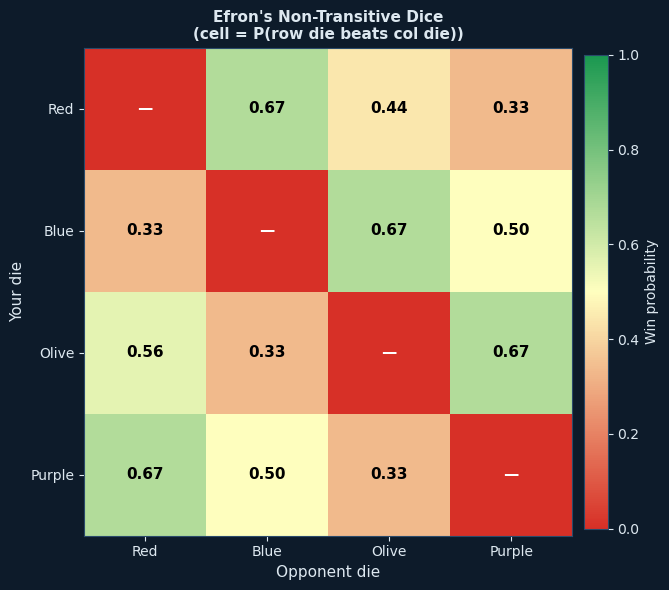

In [12]:
fig = dd.plot_win_matrix(efron, m_efron, "Efron's Non-Transitive Dice")
plt.show()

### The win cycle visualized
Arrows show who beats whom and by how much. The cycle tells us
no matter which die your opponent picks, there is always a die that beats it,
but they might then switch and beat *that* die.

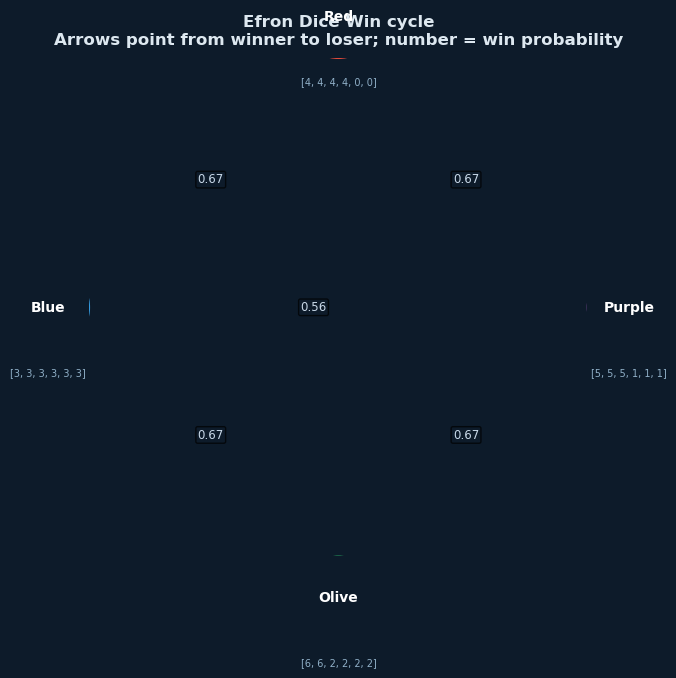

In [13]:
def draw_cycle_diagram(dice, matrix, title="Win cycle"):
    n   = len(dice)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_facecolor("#0d1b2a")

    angles = [math.pi/2 + 2*math.pi*i/n for i in range(n)]
    R = 0.7
    cx, cy = 0.5, 0.5
    pos = [(cx + R*math.cos(a), cy + R*math.sin(a)) for a in angles]

    COLORS = ["#e74c3c","#3498db","#2ecc71","#9b59b6",
              "#f39c12","#1abc9c","#e67e22","#e91e63"]

    # Draw edges for all matchups where i beats j (p > 0.5)
    for i in range(n):
        for j in range(n):
            if i != j and matrix[i][j] > 0.5:
                x0,y0 = pos[i]; x1,y1 = pos[j]
                # offset perpendicular to avoid overlap
                dx, dy = x1-x0, y1-y0
                nx, ny = -dy, dx
                norm = math.sqrt(nx*nx+ny*ny) or 1
                ox, oy = nx/norm*0.04, ny/norm*0.04
                ax.annotate(
                    "", xy=(x1+ox, y1+oy),
                    xytext=(x0+ox, y0+oy),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color=COLORS[i % len(COLORS)],
                        lw=2.5 if matrix[i][j] > 0.6 else 1.2,
                        alpha=0.85,
                    ),
                )
                mid_x = (x0+x1)/2 + ox*1.5
                mid_y = (y0+y1)/2 + oy*1.5
                ax.text(mid_x, mid_y, f"{matrix[i][j]:.2f}",
                        ha="center", va="center", fontsize=8.5,
                        color="#c8d8e8",
                        bbox=dict(boxstyle="round,pad=0.15",
                                  facecolor="#0d1b2a", alpha=0.7))

    # Draw nodes
    for i, (x, y) in enumerate(pos):
        color = COLORS[i % len(COLORS)]
        circle = plt.Circle((x, y), 0.10, color=color, zorder=4)
        ax.add_patch(circle)
        ax.text(x, y, dice[i].name, ha="center", va="center",
                fontsize=10, fontweight="bold", color="white", zorder=5)
        faces_str = str(dice[i].faces)
        ax.text(x, y - 0.145, faces_str, ha="center", va="top",
                fontsize=7, color="#90b0c8")

    ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

draw_cycle_diagram(efron, m_efron,
    "Efron Dice Win cycle\nArrows point from winner to loser; number = win probability")

### Simulation vs exact probability

`win_probability()` computes the exact result by enumerating all face combinations.
Let's verify it against simulation to confirm both are correct.

In [14]:
def simulate_matchups(dice, n_rolls=50_000, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for i, da in enumerate(dice):
        for j, db in enumerate(dice):
            if i >= j:
                continue
            a_rolls = rng.choice(da.faces, size=n_rolls)
            b_rolls = rng.choice(db.faces, size=n_rolls)
            results[(da.name, db.name)] = (
                (a_rolls > b_rolls).mean(),
                (b_rolls > a_rolls).mean(),
            )
    return results

sim = simulate_matchups(efron)

# Build exact from the same i < j pairs as sim 
exact = {}
for i, da in enumerate(efron):
    for j, db in enumerate(efron):
        if i < j:
            exact[(da.name, db.name)] = (m_efron[i][j], m_efron[j][i])

print(f"Simulated vs exact win rates (50,000 rolls each)")
print(f"{'Matchup':<22} {'Simulated':>12} {'Exact':>10} {'Error':>8}")
print("-" * 58)
for (a_name, b_name), (sim_a, sim_b) in sim.items():
    ex_a, ex_b = exact[(a_name, b_name)]
    err = abs(sim_a - ex_a)
    print(f"  {a_name} vs {b_name:<10} {sim_a:>10.4f}   {ex_a:>8.4f}  {err:>8.5f}")

Simulated vs exact win rates (50,000 rolls each)
Matchup                   Simulated      Exact    Error
----------------------------------------------------------
  Red vs Blue           0.6671     0.6667   0.00041
  Red vs Olive          0.4438     0.4444   0.00066
  Red vs Purple         0.3321     0.3333   0.00119
  Blue vs Olive          0.6646     0.6667   0.00211
  Blue vs Purple         0.5011     0.5000   0.00114
  Olive vs Purple         0.6680     0.6667   0.00133


## Part 2: Face Distributions and Why Mean Isn't Everything
All four Efron dice have the same mean (3.0). A naive ranking by expected
value would call them tied. But they clearly aren't, the *shape* of
the distribution matters as much as its center.

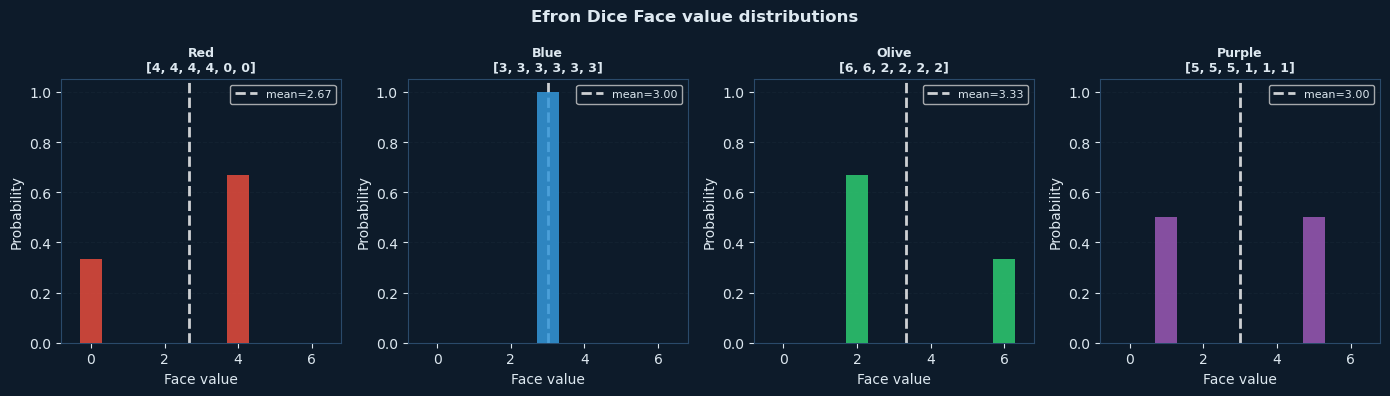


Notice: all four dice have equal means (3.00).
Same expected value, but very different win rates against each other.
Variance in the distribution (not the mean) drives who wins.


In [15]:
def draw_face_distributions(dice, title="Die face distributions"):
    n  = len(dice)
    COLORS = ["#e74c3c","#3498db","#2ecc71","#9b59b6",
              "#f39c12","#1abc9c","#e67e22","#e91e63"]

    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4), sharey=False)
    if n == 1: axes = [axes]

    all_faces = [f for d in dice for f in d.faces]
    vmin, vmax = min(all_faces), max(all_faces)
    face_vals  = sorted(set(all_faces))

    for ax, die, color in zip(axes, dice, COLORS):
        counts = {f: die.faces.count(f) / len(die.faces) for f in face_vals}
        xs     = list(counts.keys())
        ys     = list(counts.values())
        ax.bar(xs, ys, color=color, alpha=0.85, width=0.6, zorder=3)
        ax.axvline(die.mean, color="white", linewidth=2, linestyle="--",
                   alpha=0.8, label=f"mean={die.mean:.2f}")
        ax.set_xlim(vmin - 0.8, vmax + 0.8)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Face value"); ax.set_ylabel("Probability")
        ax.set_title(f"{die.name}\n{die.faces}", fontsize=9, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

draw_face_distributions(efron, "Efron Dice Face value distributions")
print()
print("Notice: all four dice have equal means (3.00).")
print("Same expected value, but very different win rates against each other.")
print("Variance in the distribution (not the mean) drives who wins.")

### Mean vs win rate across many random dice

If mean determined everything, every die with a higher mean than d6 would
beat d6, and vice versa. Let's test that assumption with 400 random dice.

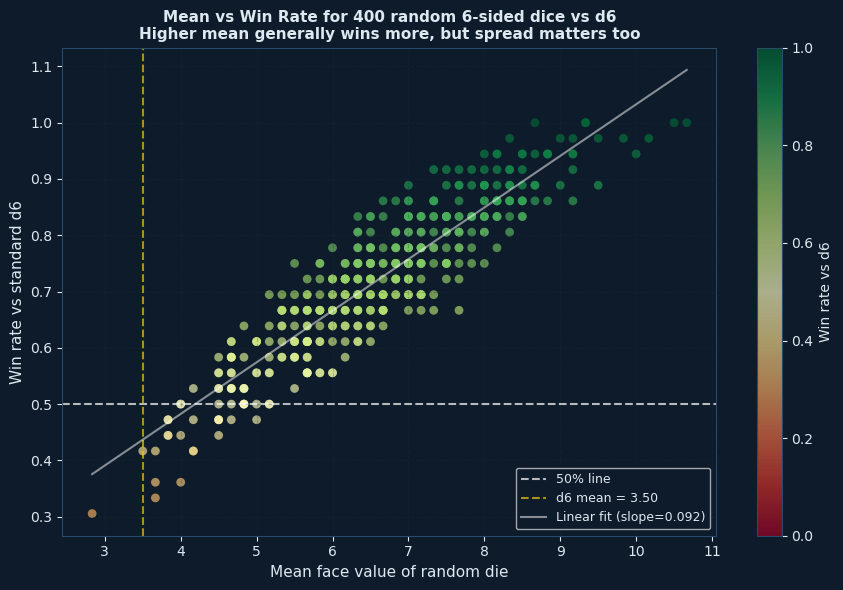

Dice with mean < 3.5 that still beat d6 more than 50%: 0 of 400
Variance in face distribution can compensate for a lower mean.


In [16]:
# Generate many random 6-sided dice and plot mean vs win rate against the standard d6
rng = np.random.default_rng(99)
d6  = dd.Die("d6", [1,2,3,4,5,6])

n_dice = 400
means, win_rates = [], []

for _ in range(n_dice):
    faces = sorted(rng.integers(1, 13, size=6).tolist())
    d     = dd.Die("rnd", faces)
    means.append(d.mean)
    win_rates.append(dd.win_probability(d, d6))

means     = np.array(means)
win_rates = np.array(win_rates)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(means, win_rates, c=win_rates, cmap="RdYlGn",
                vmin=0, vmax=1, alpha=0.65, s=40, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Win rate vs d6")
ax.axhline(0.5, color="white", linewidth=1.5, linestyle="--", alpha=0.7, label="50% line")
ax.axvline(d6.mean, color="#f1c40f", linewidth=1.5, linestyle="--",
           alpha=0.7, label=f"d6 mean = {d6.mean:.2f}")

# Fit a line
m, b = np.polyfit(means, win_rates, 1)
x_fit = np.linspace(means.min(), means.max(), 100)
ax.plot(x_fit, m*x_fit + b, color="white", linewidth=1.5,
        alpha=0.5, label=f"Linear fit (slope={m:.3f})")

ax.set_xlabel("Mean face value of random die", fontsize=11)
ax.set_ylabel("Win rate vs standard d6", fontsize=11)
ax.set_title("Mean vs Win Rate for 400 random 6-sided dice vs d6\n"
             "Higher mean generally wins more, but spread matters too",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Show outliers: dice that beat d6 despite lower mean
below_mean_winners = [(m, w) for m, w in zip(means, win_rates)
                      if m < d6.mean and w > 0.5]
print(f"Dice with mean < {d6.mean} that still beat d6 more than 50%: "
      f"{len(below_mean_winners)} of {n_dice}")
print("Variance in face distribution can compensate for a lower mean.")

## Part 3: Dominant Dice and Balance
A dominant die beats *every* other die more than 55% of the time.
That's bad for game design: it creates an obvious best choice and
makes the other dice irrelevant.

Non-transitive sets are interesting precisely because no dominant die exists.

UNBALANCED SET
  Die('Strong', faces=[5, 5, 5, 5, 5, 5], μ=5.00, σ=0.00)
  Die('Normal', faces=[1, 2, 3, 4, 5, 6], μ=3.50, σ=1.71)
  Die('Weak', faces=[1, 1, 2, 2, 3, 3], μ=2.00, σ=0.82)

Dominant die: Strong
This die beats all others more than 55% of the time.
Bad for game balance as a dominant strategy exists.


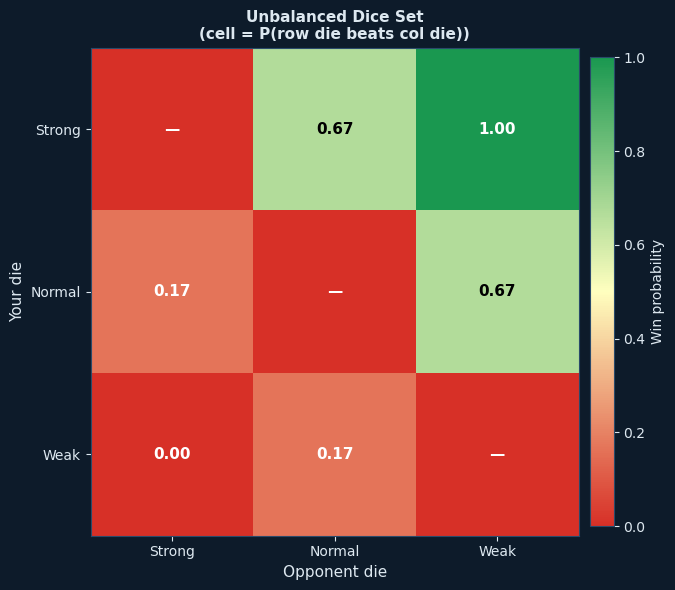

In [17]:
unbalanced = dd.UNBALANCED
m_unbal = dd.build_win_matrix(unbalanced)

print("UNBALANCED SET")
for d in unbalanced: print(" ", d)

dominant = dd.has_dominant_die(m_unbal)
if dominant is not None:
    print(f"\nDominant die: {unbalanced[dominant].name}")
    print("This die beats all others more than 55% of the time.")
    print("Bad for game balance as a dominant strategy exists.")
else:
    print("No dominant die found.")

fig = dd.plot_win_matrix(unbalanced, m_unbal, "Unbalanced Dice Set")
plt.show()

## Part 4: Design Your Own Dice
Edit the face lists below and the notebook will compute the full win matrix,
check for dominance, and visualize the win cycle.

**Design challenge:** can you make a 4-die set where each die beats exactly
one other and loses to exactly one other, in other words- a perfect cycle?

Die('Spike', faces=[1, 1, 1, 1, 1, 12], μ=2.83, σ=4.10)
Die('Steady', faces=[3, 3, 4, 4, 4, 4], μ=3.67, σ=0.47)
Die('Gamble', faces=[1, 1, 6, 6, 6, 6], μ=4.33, σ=2.36)
Die('Solid', faces=[3, 4, 4, 4, 5, 5], μ=4.17, σ=0.69)

Dominant die: Gamble consider rebalancing.


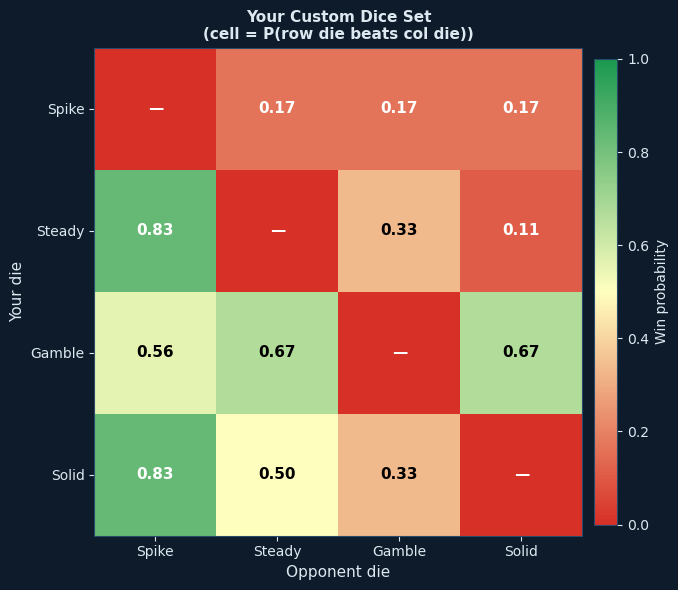

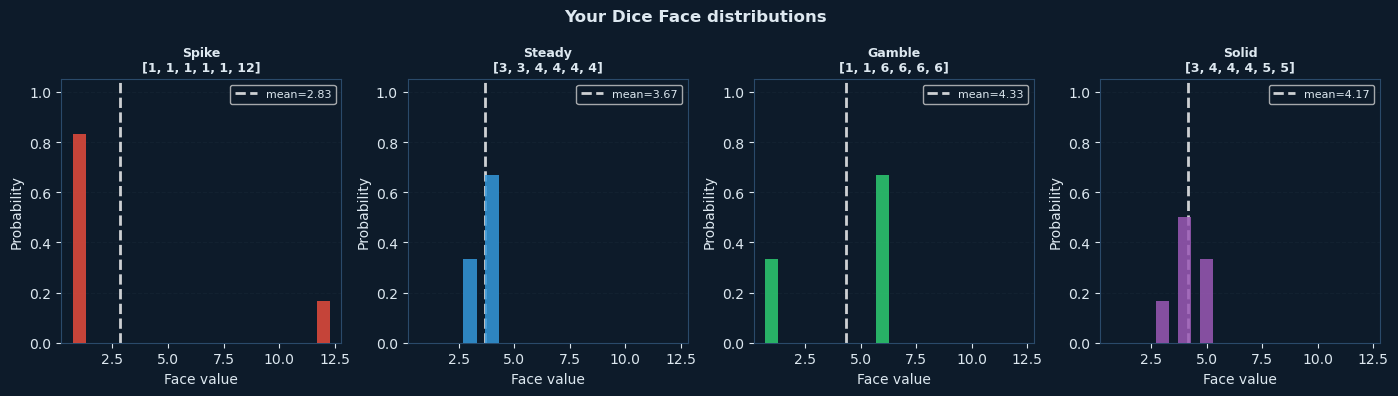

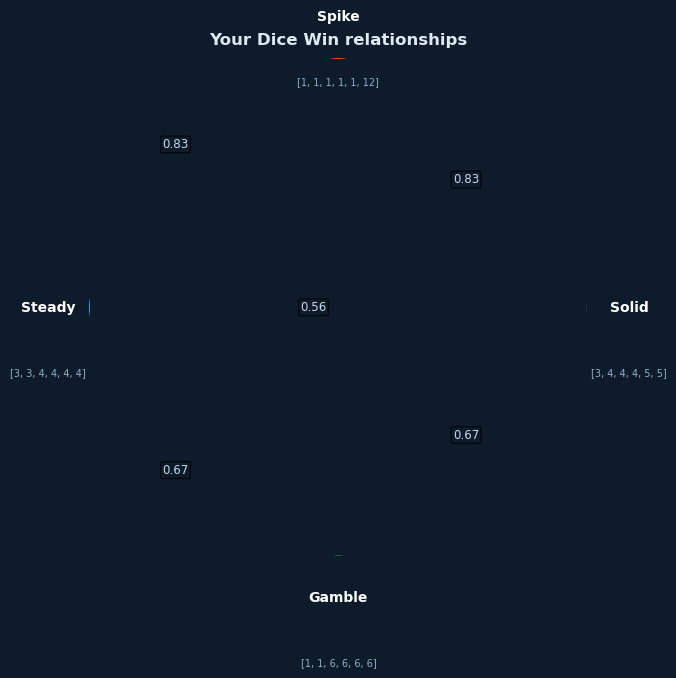

In [18]:
# Design your own dice and check the win matrix
# Edit these lists freely for any number of faces, any values

my_dice = [
    dd.Die("Spike",   [1, 1, 1, 1, 1, 12]),   # high variance, low mean
    dd.Die("Steady",  [3, 3, 4, 4, 4,  4]),   # low variance, moderate mean
    dd.Die("Gamble",  [1, 1, 6, 6, 6,  6]),   # bimodal
    dd.Die("Solid",   [3, 4, 4, 4, 5,  5]),   # reliable mid-range
]

for d in my_dice:
    print(d)

m_custom = dd.build_win_matrix(my_dice)
dominant = dd.has_dominant_die(m_custom)

if dominant is not None:
    print(f"\nDominant die: {my_dice[dominant].name} consider rebalancing.")
else:
    print("\nNo dominant die: these dice are balanced (non-transitive or near-equal).")

fig = dd.plot_win_matrix(my_dice, m_custom, "Your Custom Dice Set")
plt.show()

draw_face_distributions(my_dice, "Your Dice Face distributions")
draw_cycle_diagram(my_dice, m_custom, "Your Dice Win relationships")

## Part 5: Searching for Balanced Sets
Instead of designing by intuition, let's search randomly.
We'll generate thousands of 3-die sets and keep the ones
that are non-transitive with no dominant die.

In [19]:
# Search for balanced non-transitive sets automatically
# A "perfectly balanced" set: every die beats at least one other,
# loses to at least one, and no dominant die exists

def random_die(name, n_faces=6, lo=1, hi=9, rng=None):
    if rng is None: rng = np.random.default_rng()
    return dd.Die(name, sorted(rng.integers(lo, hi+1, size=n_faces).tolist()))

def is_non_transitive(matrix):
    n = matrix.shape[0]
    for i in range(n):
        wins   = [j for j in range(n) if j != i and matrix[i][j] > 0.5]
        losses = [j for j in range(n) if j != i and matrix[i][j] < 0.5]
        if not wins or not losses:
            return False
    return True

rng   = np.random.default_rng(7)
found = []

print("Searching for non-transitive 3-die sets (no dominant die)...")
for attempt in range(10_000):
    names = ["A","B","C"]
    dice  = [random_die(n, rng=rng) for n in names]
    m     = dd.build_win_matrix(dice)
    if dd.has_dominant_die(m) is None and is_non_transitive(m):
        found.append((dice, m))
    if len(found) >= 5:
        break

print(f"Found {len(found)} non-transitive balanced sets in {attempt+1} attempts")
print()

for i, (dice_set, m) in enumerate(found):
    print(f"Set {i+1}:")
    for d in dice_set:
        print(f"  {d.name}: {d.faces}  mean={d.mean:.2f}")
    for ia in range(3):
        for ib in range(ia+1, 3):
            print(f"  {dice_set[ia].name} vs {dice_set[ib].name}: "
                  f"P({dice_set[ia].name} wins)={m[ia][ib]:.3f}")
    print()

# Visualize the first found set
if found:
    best_dice, best_m = found[0]
    fig = dd.plot_win_matrix(best_dice, best_m,
                              "Randomly Discovered Non-Transitive Set")
    plt.show()
    draw_cycle_diagram(best_dice, best_m, "Win cycle: discovered set")

Searching for non-transitive 3-die sets (no dominant die)...
Found 0 non-transitive balanced sets in 10000 attempts



## Summary

| Concept | Key result |
|---|---|
| Non-transitive dice | Rock-paper-scissors structure; no globally best die |
| Win probability | Exact enumeration of all face pairs; O(n²) per matchup |
| Mean vs win rate | Higher mean generally wins more, but variance can compensate |
| Dominant die | Beats all others > 55% of the time; a sign of poor game balance |
| Balanced set | No dominant die; the right choice always depends on the opponent |

### What to explore next

- **Weighted dice**: what if some faces appear more often than others?
  How does that change the win probability calculation?
- **Best-of-N games**: does the non-transitive cycle hold up over multiple
  rolls, or does variance wash out and mean take over?
- **Four-player balance**: can you build a 4-die set where every die beats
  exactly two others and loses to exactly two? (Hint: think directed graphs)
- **Efron dice variants**: Schur dice, Oskar dice, and Miwin's dice are
  other classical non-transitive sets worth comparing